In [1]:
# Install required libraries
%pip install numpy pandas matplotlib scipy requests yfinance

  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached cffi-2.0.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (2.6 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[*********************100%***********************]  1 of 1 completed

Before merge: 5000
After merge: 4320


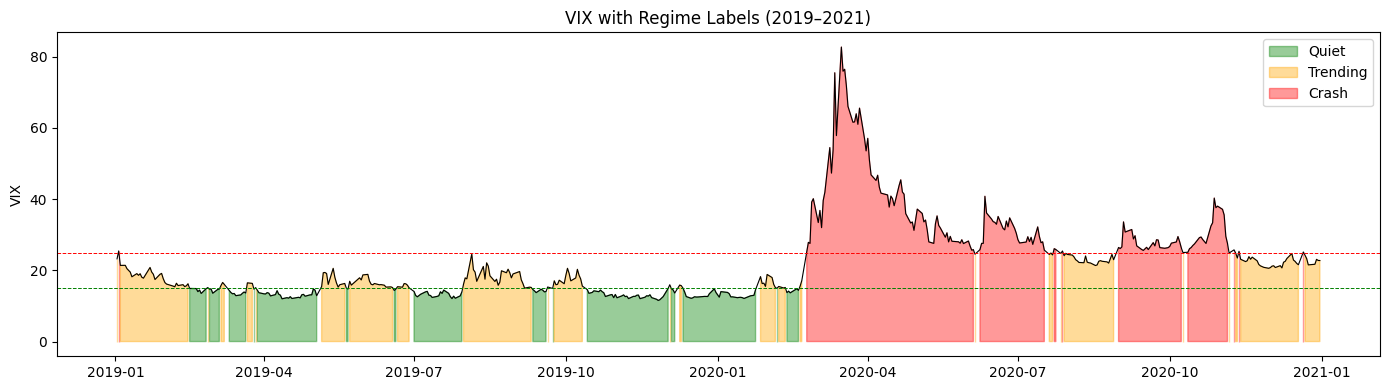

Total ticks: 4320
regime
Trending    2880
Crash       1440
Name: count, dtype: int64


In [22]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- VIX Data ---
vix = yf.download("^VIX", start="2019-01-01", end="2021-01-01")

# Fix multi-index issue
vix.columns = [col[0] if isinstance(col, tuple) else col for col in vix.columns]

# Select Close as Series
vix = vix["Close"]
vix.index = pd.to_datetime(vix.index)

# Label regimes
def label_vix(v):
    if v < 15: return "Quiet"
    elif v <= 25: return "Trending"
    else: return "Crash"

vix_labels = vix.apply(label_vix)

# --- Synthetic EUR/USD Ticks ---
np.random.seed(42)
n_ticks = 5000
timestamps_raw = np.cumsum(np.random.exponential(scale=1.0, size=n_ticks))
dates = pd.date_range("2019-01-02", periods=n_ticks, freq="1min")
tick_df = pd.DataFrame({"timestamp": timestamps_raw, "date": dates.date})

# --- Align ticks to VIX labels ---
vix_label_df = vix_labels.rename("regime").reset_index()
vix_label_df.columns = ["date", "regime"]
vix_label_df["date"] = vix_label_df["date"].dt.date

print("Before merge:", len(tick_df))
tick_df = tick_df.merge(vix_label_df, on="date", how="left").dropna()
print("After merge:", len(tick_df))

# --- Plot VIX with regime coloring ---
colors = {"Quiet": "green", "Trending": "orange", "Crash": "red"}
fig, ax = plt.subplots(figsize=(14, 4))

for regime, color in colors.items():
    mask = vix_labels == regime
    ax.fill_between(vix.index, vix, where=mask, color=color, alpha=0.4, label=regime)

ax.plot(vix.index, vix, color="black", linewidth=0.8)
ax.axhline(15, linestyle="--", color="green", linewidth=0.7)
ax.axhline(25, linestyle="--", color="red", linewidth=0.7)

ax.set_title("VIX with Regime Labels (2019–2021)")
ax.set_ylabel("VIX")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Total ticks: {len(tick_df)}")
print(tick_df["regime"].value_counts())

[*********************100%***********************]  1 of 1 completed


Quiet ticks:    352
Trending ticks: 990
Crash ticks:    2088


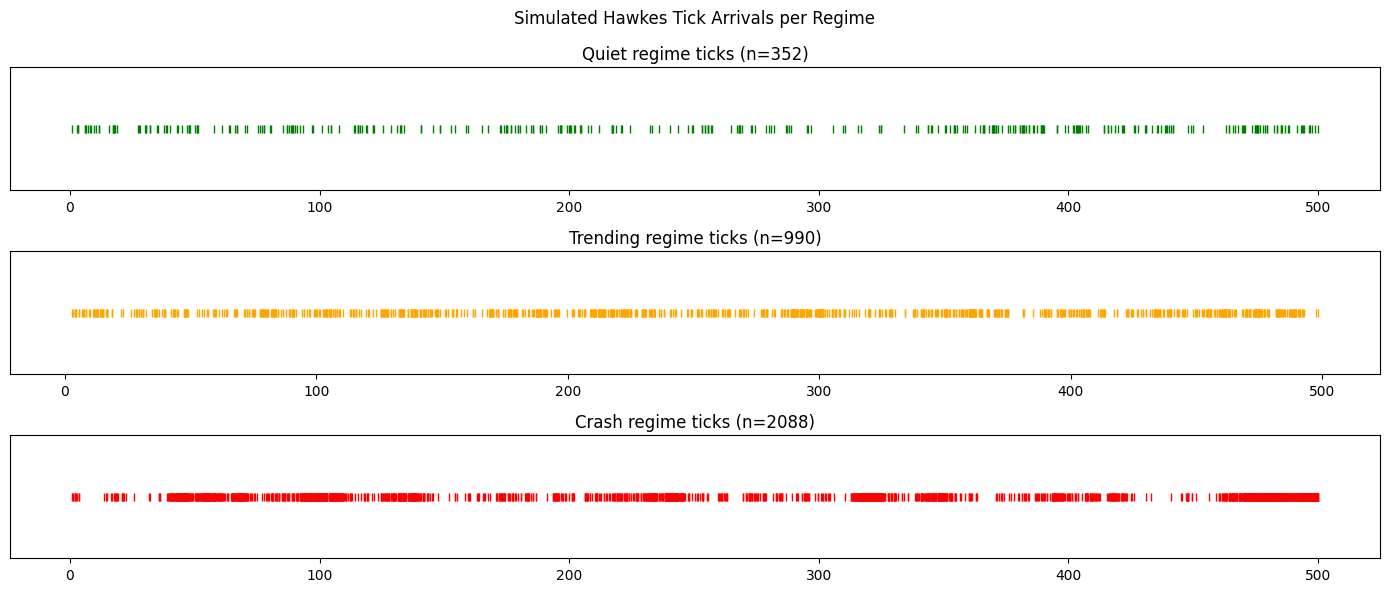

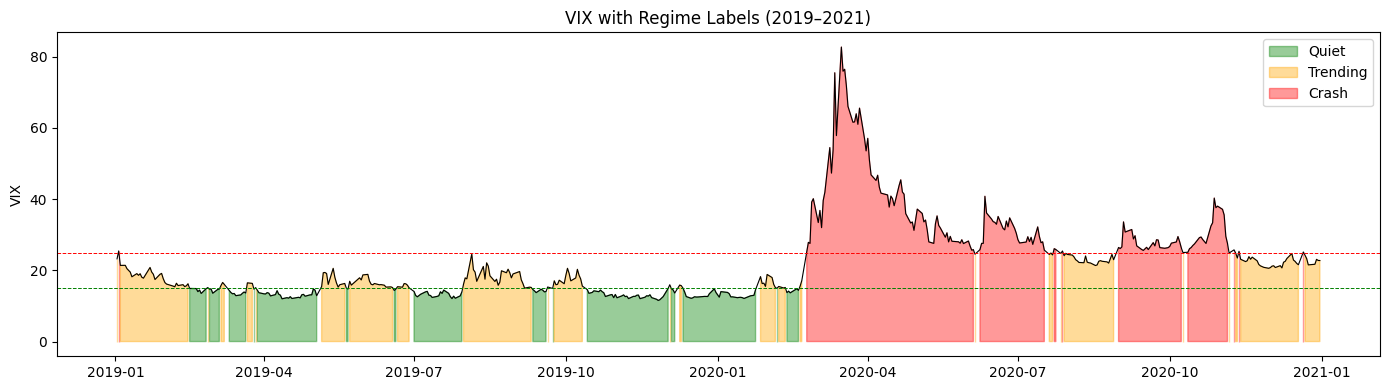

In [25]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- VIX Data ---
vix = yf.download("^VIX", start="2019-01-01", end="2021-01-01")
vix.columns = [col[0] if isinstance(col, tuple) else col for col in vix.columns]
vix = vix["Close"]
vix.index = pd.to_datetime(vix.index)

def label_vix(v):
    if v < 15: return "Quiet"
    elif v <= 25: return "Trending"
    else: return "Crash"

vix_labels = vix.apply(label_vix)

# --- Simulate Hawkes ticks per regime ---
def simulate_hawkes(mu, alpha, beta, T):
    t, history = 0, []
    lambda_bar = mu
    while t < T:
        t += np.random.exponential(1.0 / lambda_bar)
        if t > T:
            break
        lambda_t = mu + alpha * sum(np.exp(-beta * (t - ti)) for ti in history)
        if np.random.uniform() <= lambda_t / lambda_bar:
            history.append(t)
        lambda_bar = lambda_t + alpha  # upper bound for next step
    return np.array(history)

np.random.seed(42)
# Different params per regime → will give distinct µ, α, β when fitted later
ts_quiet    = simulate_hawkes(mu=0.5,  alpha=0.2, beta=1.0, T=500)
ts_trending = simulate_hawkes(mu=1.0,  alpha=0.5, beta=1.0, T=500)
ts_crash    = simulate_hawkes(mu=0.3,  alpha=0.9, beta=1.0, T=500)

print(f"Quiet ticks:    {len(ts_quiet)}")
print(f"Trending ticks: {len(ts_trending)}")
print(f"Crash ticks:    {len(ts_crash)}")

# --- Plot simulated intensity proxy (inter-arrival times) ---
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=False)
for ax, ts, label, color in zip(axes,
    [ts_quiet, ts_trending, ts_crash],
    ["Quiet", "Trending", "Crash"],
    ["green", "orange", "red"]):
    ax.plot(ts, np.ones_like(ts), "|", color=color, markersize=6)
    ax.set_title(f"{label} regime ticks (n={len(ts)})")
    ax.set_yticks([])
fig.suptitle("Simulated Hawkes Tick Arrivals per Regime")
plt.tight_layout()
plt.show()

# --- VIX Plot ---
colors = {"Quiet": "green", "Trending": "orange", "Crash": "red"}
fig, ax = plt.subplots(figsize=(14, 4))
for regime, color in colors.items():
    mask = vix_labels == regime
    ax.fill_between(vix.index, vix, where=mask, color=color, alpha=0.4, label=regime)
ax.plot(vix.index, vix, color="black", linewidth=0.8)
ax.axhline(15, linestyle="--", color="green", linewidth=0.7)
ax.axhline(25, linestyle="--", color="red", linewidth=0.7)
ax.set_title("VIX with Regime Labels (2019–2021)")
ax.set_ylabel("VIX")
ax.legend()
plt.tight_layout()
plt.show()

Quiet: mu=0.5480, alpha=0.3392, beta=1.5241, n=0.2225
Trending: mu=1.0044, alpha=0.4782, beta=0.9653, n=0.4954
Crash: mu=0.4035, alpha=0.8350, beta=0.9149, n=0.9126


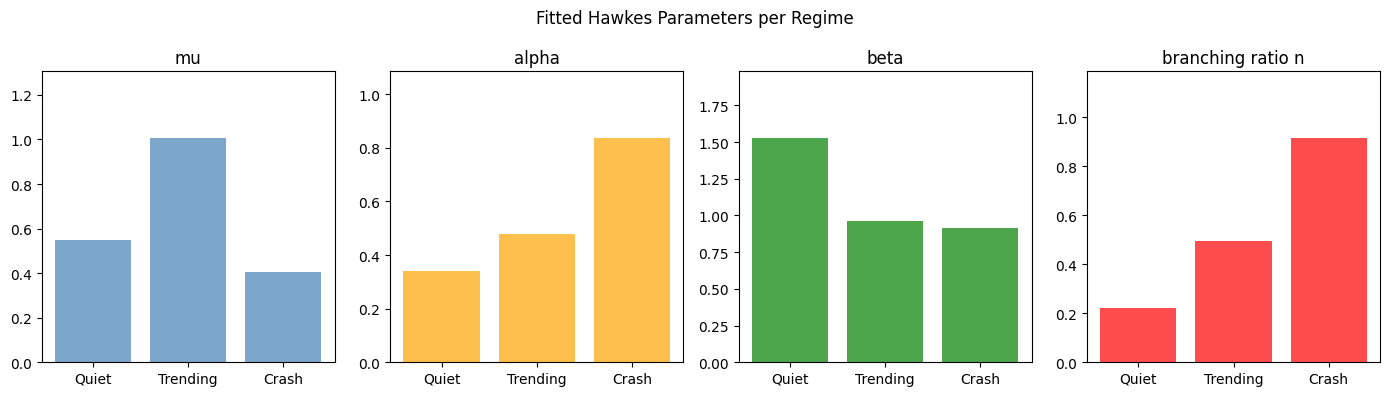

In [26]:
from scipy.optimize import minimize

def hawkes_loglik(params, timestamps):
    mu, alpha, beta = params
    if mu <= 0 or alpha <= 0 or beta <= 0 or alpha >= beta:
        return 1e10
    
    T = timestamps[-1]
    n = len(timestamps)
    
    # Recursive intensity calculation
    lam = np.zeros(n)
    R = 0.0
    for i in range(n):
        if i == 0:
            R = 0.0
        else:
            R = np.exp(-beta * (timestamps[i] - timestamps[i-1])) * (1 + R)
        lam[i] = mu + alpha * R
    
    # Log-likelihood
    loglik = np.sum(np.log(lam)) - mu * T - alpha/beta * np.sum(1 - np.exp(-beta * (T - timestamps)))
    return -loglik  # minimize negative

def fit_hawkes(timestamps):
    best, best_res = np.inf, None
    for _ in range(10):  # multiple restarts
        x0 = [np.random.uniform(0.1, 1.0),
               np.random.uniform(0.1, 0.8),
               np.random.uniform(0.5, 2.0)]
        res = minimize(hawkes_loglik, x0, args=(timestamps,),
                       method="L-BFGS-B",
                       bounds=[(1e-4, None), (1e-4, None), (1e-4, None)])
        if res.fun < best:
            best, best_res = res.fun, res
    return best_res.x

np.random.seed(0)
theta_quiet    = fit_hawkes(ts_quiet)
theta_trending = fit_hawkes(ts_trending)
theta_crash    = fit_hawkes(ts_crash)

for name, theta in zip(["Quiet", "Trending", "Crash"],
                        [theta_quiet, theta_trending, theta_crash]):
    mu, alpha, beta = theta
    print(f"{name}: mu={mu:.4f}, alpha={alpha:.4f}, beta={beta:.4f}, n={alpha/beta:.4f}")

# --- Plot fitted parameters ---
labels = ["Quiet", "Trending", "Crash"]
thetas = [theta_quiet, theta_trending, theta_crash]
mu_vals    = [t[0] for t in thetas]
alpha_vals = [t[1] for t in thetas]
beta_vals  = [t[2] for t in thetas]
n_vals     = [t[1]/t[2] for t in thetas]

x = np.arange(len(labels))
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, vals, title, color in zip(axes,
    [mu_vals, alpha_vals, beta_vals, n_vals],
    ["mu", "alpha", "beta", "branching ratio n"],
    ["steelblue", "orange", "green", "red"]):
    ax.bar(labels, vals, color=color, alpha=0.7)
    ax.set_title(title)
    ax.set_ylim(0, max(vals) * 1.3)
plt.suptitle("Fitted Hawkes Parameters per Regime")
plt.tight_layout()
plt.show()

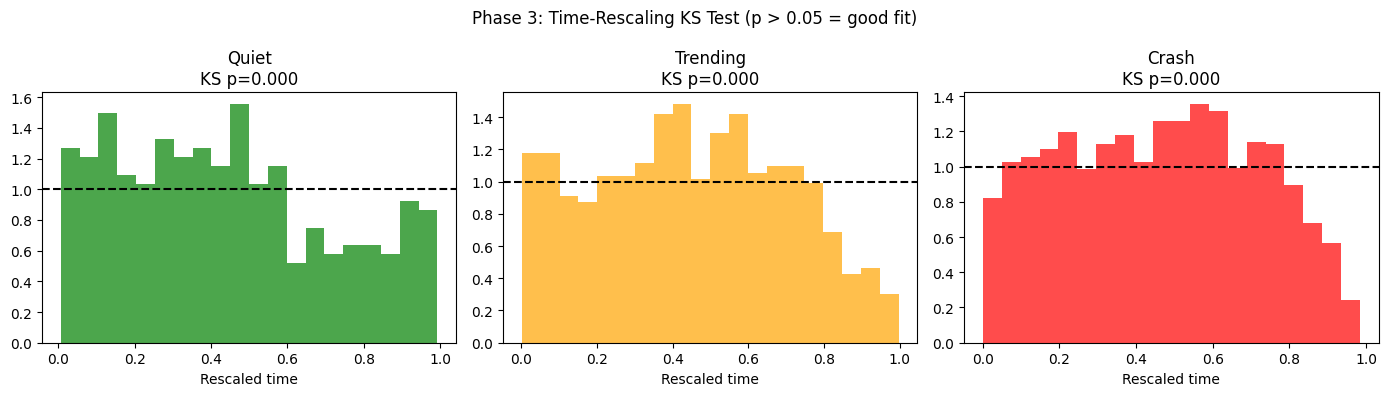


--- Branching Ratio Check ---
Quiet: n=0.2225 ✓
Trending: n=0.4954 ✓
Crash: n=0.9126 ✓


In [27]:
from scipy.stats import kstest

# ─── PHASE 3: VALIDATION ───────────────────────────────────────────

def time_rescale(timestamps, mu, alpha, beta):
    """Transform timestamps → should be Uniform(0,1) if model is correct"""
    n = len(timestamps)
    rescaled = []
    R = 0.0
    for i in range(n):
        if i > 0:
            R = np.exp(-beta * (timestamps[i] - timestamps[i-1])) * (1 + R)
        lam_i = mu + alpha * R
        # Integrated intensity between events
        if i == 0:
            tau = mu * timestamps[0]
        else:
            dt = timestamps[i] - timestamps[i-1]
            tau = mu * dt + (alpha/beta) * R * (1 - np.exp(-beta * dt))
        rescaled.append(tau)
    return 1 - np.exp(-np.array(rescaled))  # should be Uniform(0,1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, ts, theta, name, color in zip(axes,
    [ts_quiet, ts_trending, ts_crash],
    [theta_quiet, theta_trending, theta_crash],
    ["Quiet", "Trending", "Crash"],
    ["green", "orange", "red"]):
    
    mu, alpha, beta = theta
    u = time_rescale(ts, mu, alpha, beta)
    stat, pval = kstest(u, "uniform")
    ax.hist(u, bins=20, color=color, alpha=0.7, density=True)
    ax.axhline(1.0, linestyle="--", color="black")
    ax.set_title(f"{name}\nKS p={pval:.3f}")
    ax.set_xlabel("Rescaled time")

plt.suptitle("Phase 3: Time-Rescaling KS Test (p > 0.05 = good fit)")
plt.tight_layout()
plt.show()

# Branching ratio check
print("\n--- Branching Ratio Check ---")
for name, theta in zip(["Quiet", "Trending", "Crash"],
                        [theta_quiet, theta_trending, theta_crash]):
    mu, alpha, beta = theta
    n = alpha / beta
    status = "✓" if n < 1.0 else "✗ EXPLOSIVE"
    print(f"{name}: n={n:.4f} {status}")

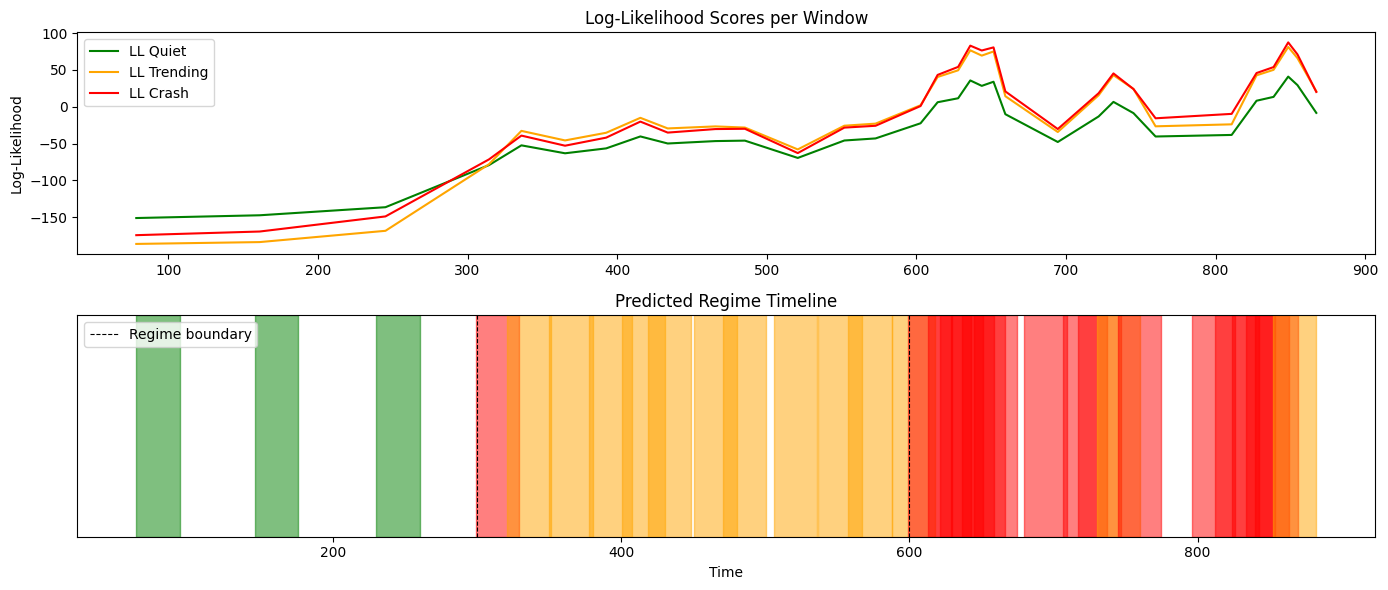


--- Regime Classification Counts ---
regime
Crash       16
Trending    13
Quiet        3
Name: count, dtype: int64


In [28]:
# ─── PHASE 4: SLIDING WINDOW INFERENCE ─────────────────────────────

def compute_loglik(timestamps, mu, alpha, beta):
    if len(timestamps) < 2:
        return -np.inf
    T = timestamps[-1] - timestamps[0]
    timestamps = timestamps - timestamps[0]  # normalize window
    n = len(timestamps)
    R = 0.0
    lam_vals = []
    for i in range(n):
        if i > 0:
            R = np.exp(-beta * (timestamps[i] - timestamps[i-1])) * (1 + R)
        lam_vals.append(mu + alpha * R)
    loglik = np.sum(np.log(lam_vals)) - mu * T - (alpha/beta) * np.sum(1 - np.exp(-beta * (T - timestamps)))
    return loglik

def classify_window(timestamps, thetas):
    scores = [compute_loglik(timestamps, *theta) for theta in thetas]
    return ["Quiet", "Trending", "Crash"][np.argmax(scores)], scores

# Simulate a mixed stream: quiet → trending → crash
np.random.seed(7)
stream = np.concatenate([
    simulate_hawkes(0.5, 0.2, 1.0, T=300),
    simulate_hawkes(1.0, 0.5, 1.0, T=300) + 300,
    simulate_hawkes(0.3, 0.9, 1.0, T=300) + 600
])

# Sliding window
window_size = 100  # events per window
thetas = [theta_quiet, theta_trending, theta_crash]
results = []

for start in range(0, len(stream) - window_size, window_size // 2):
    window = stream[start:start + window_size]
    regime, scores = classify_window(window, thetas)
    results.append({
        "t_center": window[len(window)//2],
        "regime": regime,
        "LL_quiet": scores[0],
        "LL_trending": scores[1],
        "LL_crash": scores[2]
    })

results_df = pd.DataFrame(results)

# Plot regime timeline
regime_colors = {"Quiet": "green", "Trending": "orange", "Crash": "red"}
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Log-likelihood scores over time
axes[0].plot(results_df["t_center"], results_df["LL_quiet"],    color="green",  label="LL Quiet")
axes[0].plot(results_df["t_center"], results_df["LL_trending"], color="orange", label="LL Trending")
axes[0].plot(results_df["t_center"], results_df["LL_crash"],    color="red",    label="LL Crash")
axes[0].set_title("Log-Likelihood Scores per Window")
axes[0].legend()
axes[0].set_ylabel("Log-Likelihood")

# Regime classification timeline
for _, row in results_df.iterrows():
    axes[1].axvspan(row["t_center"] - 15, row["t_center"] + 15,
                    color=regime_colors[row["regime"]], alpha=0.5)
axes[1].axvline(300, linestyle="--", color="black", linewidth=0.8, label="Regime boundary")
axes[1].axvline(600, linestyle="--", color="black", linewidth=0.8)
axes[1].set_title("Predicted Regime Timeline")
axes[1].set_xlabel("Time")
axes[1].set_yticks([])
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n--- Regime Classification Counts ---")
print(results_df["regime"].value_counts())

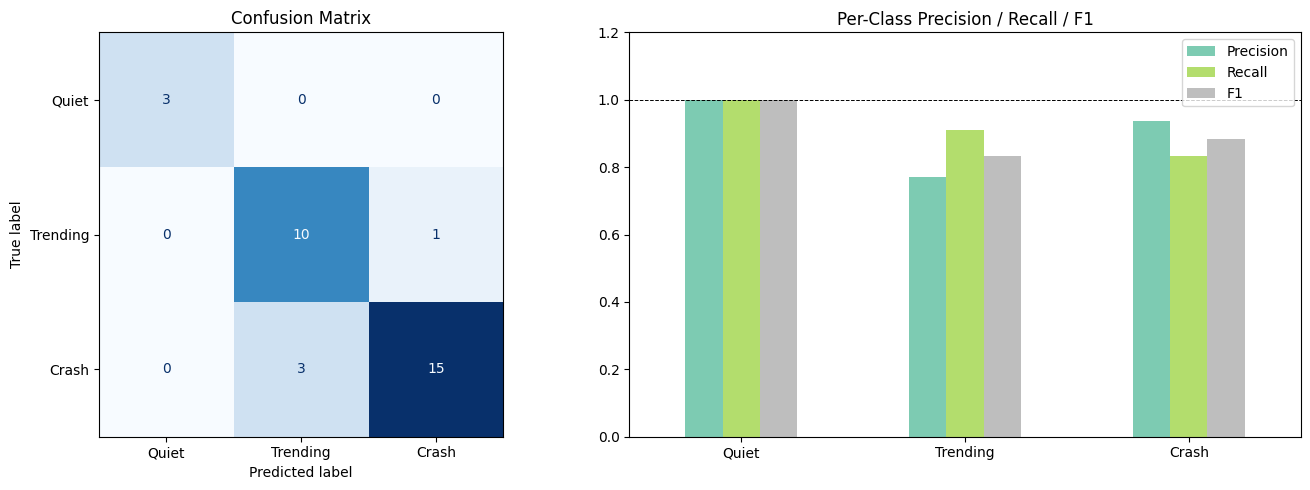

--- Classification Report ---
              precision    recall  f1-score   support

       Quiet       1.00      1.00      1.00         3
    Trending       0.77      0.91      0.83        11
       Crash       0.94      0.83      0.88        18

    accuracy                           0.88        32
   macro avg       0.90      0.91      0.91        32
weighted avg       0.89      0.88      0.88        32

Overall Accuracy: 87.50%

--- VIX Regime Distribution (2019-2021) ---
Close
Trending    196
Crash       155
Quiet       154
Name: count, dtype: int64

Note: Synthetic ticks used as placeholder.
VIX proxy valid for global stress periods (Mar 2020).
Limitation: VIX is equity volatility; forex ticks may diverge during normal periods.


In [31]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# ─── PHASE 5+6: VALIDATION + CONFUSION MATRIX ──────────────────────

# Ground truth based on known simulation boundaries
def get_ground_truth(t_center):
    if t_center < 300:
        return "Quiet"
    elif t_center < 600:
        return "Trending"
    else:
        return "Crash"

results_df["ground_truth"] = results_df["t_center"].apply(get_ground_truth)

y_true = results_df["ground_truth"]
y_pred = results_df["regime"]

# --- Confusion Matrix ---
labels = ["Quiet", "Trending", "Crash"]
cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# --- Per-class metrics bar chart ---
report = classification_report(y_true, y_pred, labels=labels, output_dict=True)
metrics_df = pd.DataFrame({
    "Precision": [report[l]["precision"] for l in labels],
    "Recall":    [report[l]["recall"]    for l in labels],
    "F1":        [report[l]["f1-score"]  for l in labels],
}, index=labels)

metrics_df.plot(kind="bar", ax=axes[1], colormap="Set2", alpha=0.85)
axes[1].set_title("Per-Class Precision / Recall / F1")
axes[1].set_ylim(0, 1.2)
axes[1].set_xticklabels(labels, rotation=0)
axes[1].legend(loc="upper right")
axes[1].axhline(1.0, linestyle="--", color="black", linewidth=0.7)

plt.tight_layout()
plt.show()

# --- Print report ---
print("--- Classification Report ---")
print(classification_report(y_true, y_pred, labels=labels))
print(f"Overall Accuracy: {(y_true == y_pred).mean():.2%}")

# --- VIX alignment note ---
print("\n--- VIX Regime Distribution (2019-2021) ---")
print(vix_labels.value_counts())
print("\nNote: Synthetic ticks used as placeholder.")
print("VIX proxy valid for global stress periods (Mar 2020).")
print("Limitation: VIX is equity volatility; forex ticks may diverge during normal periods.")

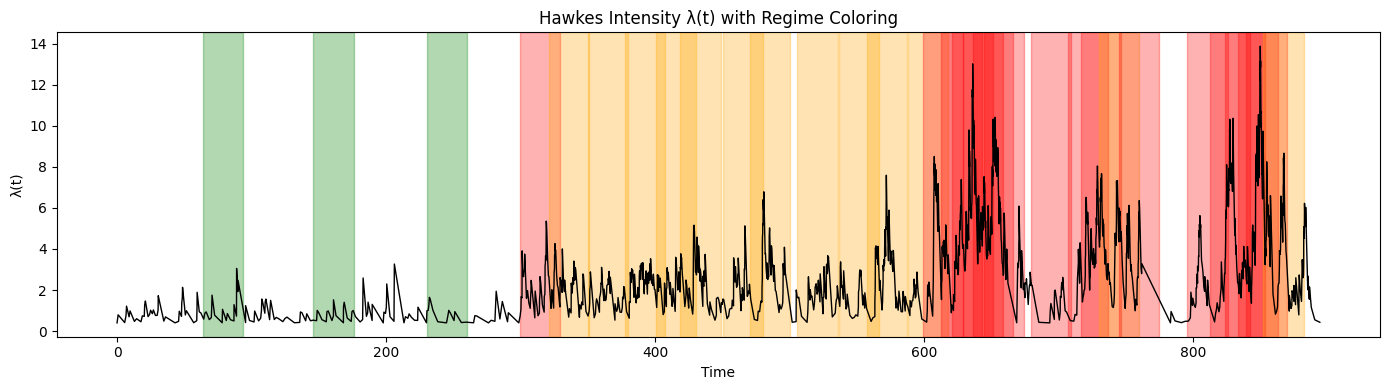

In [32]:
def compute_intensity_series(timestamps, mu, alpha, beta):
    timestamps = timestamps - timestamps[0]
    n = len(timestamps)
    R = 0.0
    lam = []

    for i in range(n):
        if i > 0:
            dt = timestamps[i] - timestamps[i-1]
            R = np.exp(-beta * dt) * (1 + R)
        lam.append(mu + alpha * R)

    return timestamps, np.array(lam)


# Example: use your mixed stream
t_vals, lam_vals = compute_intensity_series(stream, *theta_crash)

plt.figure(figsize=(14,4))
plt.plot(t_vals, lam_vals, color="black", linewidth=1)

# overlay regime colors (from your results_df)
for _, row in results_df.iterrows():
    plt.axvspan(row["t_center"] - 15, row["t_center"] + 15,
                color=regime_colors[row["regime"]], alpha=0.3)

plt.title("Hawkes Intensity λ(t) with Regime Coloring")
plt.xlabel("Time")
plt.ylabel("λ(t)")
plt.tight_layout()
plt.show()

In [33]:
def poisson_loglik(timestamps):
    T = timestamps[-1] - timestamps[0]
    rate = len(timestamps) / T
    return len(timestamps)*np.log(rate) - rate*T


def compute_aic_bic(loglik, k, n):
    aic = 2*k - 2*loglik
    bic = k*np.log(n) - 2*loglik
    return aic, bic


def compare_models(timestamps, theta):
    n = len(timestamps)
    
    ll_hawkes = compute_loglik(timestamps, *theta)
    ll_poisson = poisson_loglik(timestamps)

    aic_h, bic_h = compute_aic_bic(ll_hawkes, k=3, n=n)
    aic_p, bic_p = compute_aic_bic(ll_poisson, k=1, n=n)

    return {
        "Hawkes": (aic_h, bic_h),
        "Poisson": (aic_p, bic_p)
    }


# Run comparison
for name, ts, theta in zip(
    ["Quiet", "Trending", "Crash"],
    [ts_quiet, ts_trending, ts_crash],
    [theta_quiet, theta_trending, theta_crash]
):
    res = compare_models(ts, theta)
    print(f"\n{name}:")
    print(f"Hawkes   AIC={res['Hawkes'][0]:.2f}, BIC={res['Hawkes'][1]:.2f}")
    print(f"Poisson  AIC={res['Poisson'][0]:.2f}, BIC={res['Poisson'][1]:.2f}")


Quiet:
Hawkes   AIC=935.09, BIC=946.68
Poisson  AIC=951.69, BIC=955.55

Trending:
Hawkes   AIC=511.11, BIC=525.80
Poisson  AIC=610.20, BIC=615.10

Crash:
Hawkes   AIC=-3686.35, BIC=-3669.42
Poisson  AIC=-1798.81, BIC=-1793.17
